# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Data

In [2]:
df_sales = pd.read_excel('Complete data model.xlsx', sheet_name = 'sales')

In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Sale_ID     829262 non-null  int64         
 1   Date        829262 non-null  datetime64[ns]
 2   Store_ID    829262 non-null  int64         
 3   Product_ID  829262 non-null  int64         
 4   Units       829262 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 31.6 MB


In [4]:
df_inventory = pd.read_excel('Complete data model.xlsx', sheet_name = 'inventory')

In [5]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Store_ID       1593 non-null   int64
 1   Product_ID     1593 non-null   int64
 2   Stock_On_Hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


In [6]:
df_stores = pd.read_excel('Complete data model.xlsx', sheet_name = 'stores')

In [7]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Store_ID         50 non-null     int64         
 1   Store_Name       50 non-null     object        
 2   Store_City       50 non-null     object        
 3   Store_Location   50 non-null     object        
 4   Store_Open_Date  50 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 2.1+ KB


In [8]:
df_products = pd.read_excel('Complete data model.xlsx', sheet_name = 'products')

In [9]:
df_products['Profit'] = df_products['Profit'].astype(float)
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        35 non-null     int64  
 1   Product_Name      35 non-null     object 
 2   Product_Category  35 non-null     object 
 3   Product_Cost      35 non-null     float64
 4   Product_Price     35 non-null     float64
 5   Profit            35 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.8+ KB


# TABLES

### sales

In [10]:
df_sales.sample(5)

,Sale_ID,Date,Store_ID,Product_ID,Units
75965,75966,2022-03-18,37,2,1
502197,502198,2023-02-27,9,31,1
586724,586725,2023-04-22,24,3,7
573473,573474,2023-04-14,30,11,1
482063,482064,2023-02-13,13,6,1


### inventory

In [11]:
df_inventory.sample(5)

,Store_ID,Product_ID,Stock_On_Hand
1104,35,21,6
1525,49,3,14
832,26,24,11
1212,38,26,17
1295,41,16,17


### stores

In [12]:
df_stores.sample(5)

,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
8,9,Ciudad de Mexico 1,Cuidad de Mexico,Downtown,2004-10-15
40,41,Hermosillo 2,Hermosillo,Downtown,2014-06-01
19,20,Zacatecas 1,Zacatecas,Downtown,2009-05-29
13,14,Guanajuato 1,Guanajuato,Downtown,2007-01-31
29,30,Guadalajara 3,Guadalajara,Airport,2011-10-20


### products

In [13]:
df_products.sample(5)

,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price,Profit
28,29,Plush Pony,Toys,8.99,19.99,11.0
10,11,Etch A Sketch,Art & Crafts,10.99,20.99,10.0
18,19,Magic Sand,Art & Crafts,13.99,15.99,2.0
2,3,Barrel O' Slime,Art & Crafts,1.99,3.99,2.0
21,22,Monopoly,Games,13.99,19.99,6.0


# Data Analysis

In [14]:
# function for print probably in every question
def print_sample(x: str) -> str:
    center = x.center(150)
    text = print(150*'-', '\n', center, '\n', 150*'-')
    return text

## 1. What categories of products bring the biggest profit? Are they the same in every location?

------------------------------------------------------------------------------------------------------------------------------------------------------ 
                                           The biggest proft overall comes from Toys and Electronics products                                           
 ------------------------------------------------------------------------------------------------------------------------------------------------------


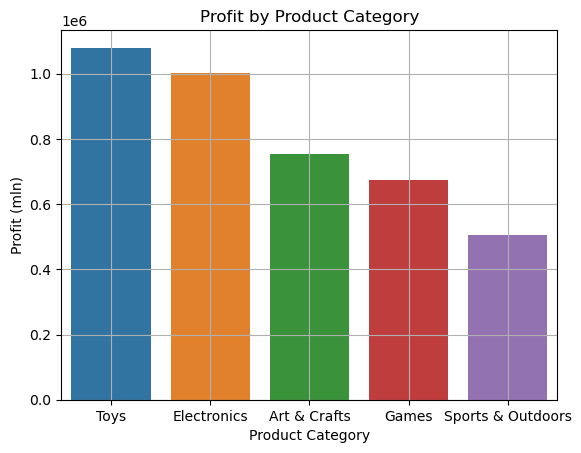

In [15]:
df_question1 = pd.merge(df_sales, df_products, on = 'Product_ID', how = 'inner')
df_question1['Profit x Units'] = df_question1['Units'] * df_question1['Profit']
df_question1 = df_question1.groupby('Product_Category').agg(
    Total_Profit = ('Profit x Units', 'sum'))
df_question1 = df_question1.sort_values('Total_Profit', ascending = False)

sns.barplot(data = df_question1, x = 'Product_Category', y = 'Total_Profit', hue = 'Product_Category')
plt.xlabel('Product Category')
plt.ylabel('Profit (mln)')
plt.title('Profit by Product Category')
plt.grid(True)
print_sample('The biggest proft overall comes from Toys and Electronics products')
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------ 
                                  The top 2 product categories in every location are always either Toys or Electronics                                  
 ------------------------------------------------------------------------------------------------------------------------------------------------------


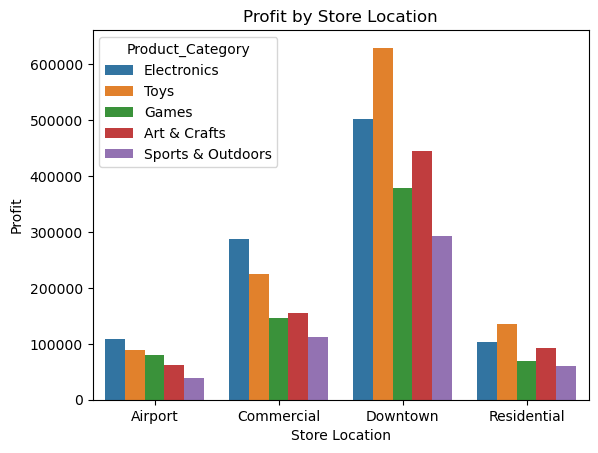

In [16]:
df_question11 = pd.merge(df_sales, df_products, on = 'Product_ID', how = 'inner')
df_question11 = pd.merge(df_question11, df_stores, on = 'Store_ID', how = 'inner')
df_question11['Profit x Units'] = df_question11['Units'] * df_question11['Profit']
df_question11 = df_question11.groupby(['Store_Location', 'Product_Category']).agg(
    Total_Profit = ('Profit x Units', 'sum'))
df_question11 = df_question11.sort_values(['Store_Location', 'Total_Profit'], ascending = [True, False])

sns.barplot(data = df_question11, x = 'Store_Location', y = 'Total_Profit', hue = 'Product_Category')
plt.xlabel('Store Location')
plt.ylabel('Profit')
plt.title('Profit by Store Location')
print_sample('The top 2 product categories in every location are always either Toys or Electronics')
plt.show()


## 2. Can any seasonal trends or patterns be identified in the sales data?

------------------------------------------------------------------------------------------------------------------------------------------------------ 
                                          The biggest overall profits comes from friday and saturday weekdays                                           
 ------------------------------------------------------------------------------------------------------------------------------------------------------


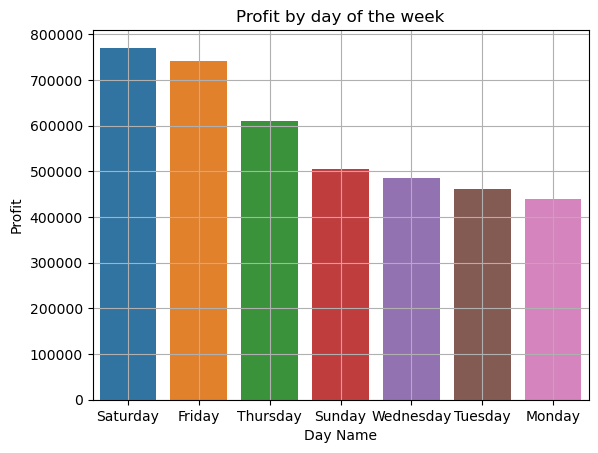

In [17]:
df_question2 = pd.merge(df_sales, df_products, on = 'Product_ID', how = 'inner')
df_question2['Profit x Units'] = df_question2['Units'] * df_question2['Profit']
df_question2['Date'] = df_question2['Date'].dt.day_name()
df_question2 = df_question2.groupby('Date').agg(
    Total_Profit = ('Profit x Units', 'sum'))
df_question2 = df_question2.sort_values('Total_Profit', ascending = False)

sns.barplot(data = df_question2, x = 'Date', y = 'Total_Profit', hue = 'Date')
plt.xlabel('Day Name')
plt.ylabel('Profit')
plt.title('Profit by day of the week')
plt.grid(True)
print_sample('The biggest overall profits comes from friday and saturday weekdays')
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------ 
                              We can notice that sports products are sold much more often during vacations and in December                              
 ------------------------------------------------------------------------------------------------------------------------------------------------------


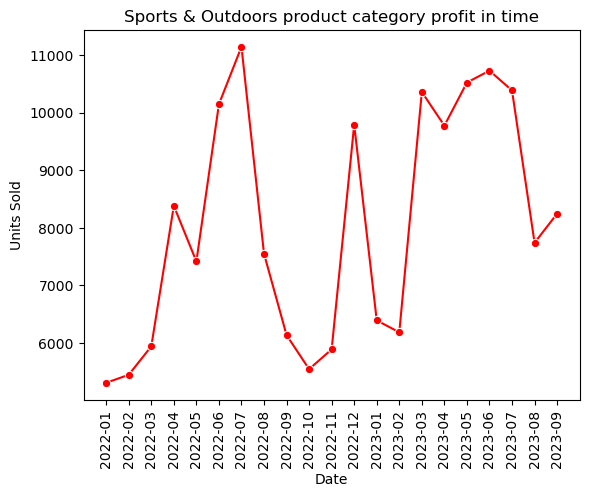

In [18]:
df_question21 = pd.merge(df_sales, df_products, on = 'Product_ID', how = 'inner')
df_question21 = df_question21[df_question21['Product_Category'] == 'Sports & Outdoors']
df_question21['Date'] = df_question21['Date'].dt.strftime('%Y-%m')
df_question21 = df_question21.groupby('Date').agg(
    Total_Units_Sold = ('Units', 'sum'))
df_question21 = df_question21.sort_values('Date', ascending = True)

sns.lineplot(data = df_question21, x = 'Date', y = 'Total_Units_Sold', marker = 'o', color = 'red')
plt.xlabel('Date')
plt.xticks(rotation = 90)
plt.ylabel('Units Sold')
plt.title('Sports & Outdoors product category profit in time')
print_sample('We can notice that sports products are sold much more often during vacations and in December')
plt.show()

## 3. What is the total cost of goods stored in inventory? How long will the inventory last without any orders?

In [19]:
df_question3 = pd.merge(df_inventory, df_stores, on = 'Store_ID', how = 'inner')
df_question3 = pd.merge(df_question3, df_products, on = 'Product_ID', how = 'inner')
df_question3['Cost x Stock'] = df_question3['Product_Cost'] * df_question3['Stock_On_Hand']
df_question3 = df_question3.groupby('Store_Name').agg(
    Cost_of_goods = ('Cost x Stock', 'sum'))
df_question3 = df_question3.sort_values('Cost_of_goods', ascending = False)
print_sample('Total cost of goods stored in every store (based on newest data)')
df_question3

------------------------------------------------------------------------------------------------------------------------------------------------------ 
                                            Total cost of goods stored in every store (based on newest data)                                            
 ------------------------------------------------------------------------------------------------------------------------------------------------------


,Cost_of_goods
Store_Name,
Ciudad de Mexico 2,8917.85
Hermosillo 1,7923.49
Hermosillo 3,7666.44
Saltillo 2,7578.93
Chihuahua 2,7565.26
Culiacan 1,7415.62
Hermosillo 2,7409.75
Chihuahua 1,7093.96
Toluca 1,6917.94


In [20]:
# calculating avg number of units sold in every store (based on last 30 days statistics)
df_question31 = pd.merge(df_sales, df_stores, on = 'Store_ID', how = 'inner')
df_question31 = df_question31[df_question31['Date'] >= df_question31['Date'].max() - pd.Timedelta(days = 30)]
df_question31 = df_question31.groupby(['Store_ID', 'Store_Name']).agg(
    Total_Units_Sold = ('Units', 'sum'))
df_question31['AVG Daily Units Sold'] = df_question31['Total_Units_Sold'] / 30

# calculating total stock available in every store
df_question32 = pd.merge(df_stores, df_inventory, on = 'Store_ID', how = 'inner')
df_question32 = df_question32.groupby(['Store_ID', 'Store_Name']).agg(
    Total_Stock_Available = ('Stock_On_Hand', 'sum'))

# merging both tables and caluclating how long will inventory last without any orders in every store
df_question33 = pd.merge(df_question31, df_question32, on = 'Store_Name', how ='inner')
df_question33['How many days will stock inventory last?'] = round(df_question33['Total_Stock_Available'] / df_question33['AVG Daily Units Sold'], 0).astype(int)
df_question33 = df_question33.sort_values('How many days will stock inventory last?', ascending = False)
df_question33.drop(columns = 'Total_Units_Sold', inplace = True)
print_sample('Based on the average daily sales from the last 30 days, the current inventory levels across toy stores are expected to last between 8 and 33 days, assuming no additional stock is ordered')
df_question33

------------------------------------------------------------------------------------------------------------------------------------------------------ 
 Based on the average daily sales from the last 30 days, the current inventory levels across toy stores are expected to last between 8 and 33 days, assuming no additional stock is ordered 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


,AVG Daily Units Sold,Total_Stock_Available,How many days will stock inventory last?
Store_Name,,,
Campeche 1,19.700000,657,33
Morelia 1,25.000000,738,30
Hermosillo 3,26.800000,756,28
Ciudad de Mexico 4,21.533333,551,26
Mexicali 1,28.133333,679,24
Chilpancingo 1,28.000000,642,23
Merida 1,33.333333,731,22
Chihuahua 2,39.466667,874,22
Guanajuato 3,29.266667,641,22


## 4. Which products are selling the best? Is there a correlation between the total profit of a product and the profit made per unit sold?

------------------------------------------------------------------------------------------------------------------------------------------------------ 
 Colorbuds looks very good — it's the highest-selling product with a high profit per unit. Some products with low profit per unit are selling relatively poorly 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


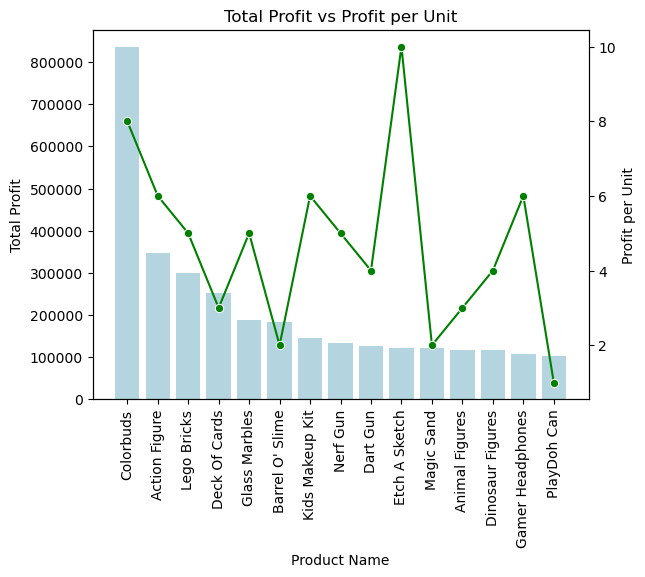

In [34]:
df_question4 = pd.merge(df_sales, df_products, on = 'Product_ID', how = 'inner')
df_question4.rename(columns = {'Profit': 'Profit per Unit'}, inplace = True)
df_question4['Profit x Units'] = df_question4['Units'] * df_question4['Profit per Unit']
df_question4 = df_question4.groupby(['Product_Name', 'Profit per Unit']).agg(
    Total_Profit = ('Profit x Units', 'sum'))
df_question4 = df_question4.sort_values('Total_Profit', ascending = False).head(15)

fig, ax1 = plt.subplots()

sns.barplot(data = df_question4, x = 'Product_Name', y = 'Total_Profit', ax = ax1, color = 'lightblue')
ax1.set_ylabel('Total Profit')
ax1.set_xlabel('Product Name')

ax2 = ax1.twinx()
sns.lineplot(data=df_question4, x = 'Product_Name', y = 'Profit per Unit', ax = ax2, color = 'green', marker = 'o')
ax2.set_ylabel('Profit per Unit')

for tick in ax1.get_xticklabels():
    tick.set_rotation(90)

plt.title('Total Profit vs Profit per Unit')
print_sample("Colorbuds looks very good — it's the highest-selling product with a high profit per unit. Some products with low profit per unit are selling relatively poorly")
plt.show()
